### Importación de datos



In [77]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


In [78]:
for t in [tienda, tienda2, tienda3, tienda4]:
    print(type(t))

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>


#1. Análisis de facturación



In [79]:
ingreso_tienda1 = tienda["Precio"].sum()
ingreso_tienda2 = tienda2["Precio"].sum()
ingreso_tienda3 = tienda3["Precio"].sum()
ingreso_tienda4 = tienda4["Precio"].sum()

ingresos = {
    "Tienda 1": ingreso_tienda1,
    "Tienda 2": ingreso_tienda2,
    "Tienda 3": ingreso_tienda3,
    "Tienda 4": ingreso_tienda4,
}

df_ingresos = pd.DataFrame(list(ingresos.items()), columns=["Tienda", "Ingreso Total"])
df_ingresos

,Tienda,Ingreso Total
0,Tienda 1,1.150880e+09
1,Tienda 2,1.116344e+09
2,Tienda 3,1.098020e+09
3,Tienda 4,1.038376e+09


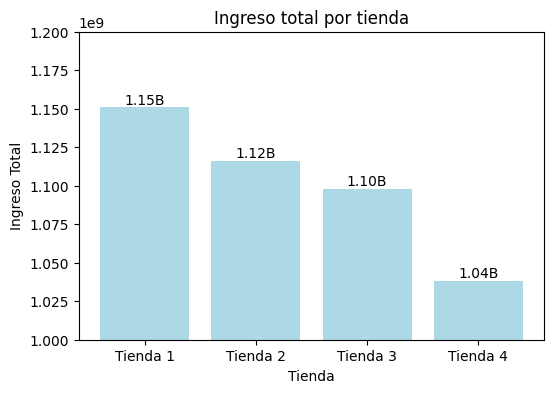

In [80]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
bars = plt.bar(df_ingresos["Tienda"], df_ingresos["Ingreso Total"], color="lightblue")

plt.title("Ingreso total por tienda")
plt.ylabel("Ingreso Total")
plt.xlabel("Tienda")
plt.ylim(1.00e9, 1.20e9)

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height(),
             f"{bar.get_height()/1e9:.2f}B",
             ha='center', va='bottom')

plt.xticks(rotation=0)
plt.show()

# 2. Ventas por categoría

In [81]:
ventas_cat_t1 = tienda["Categoría del Producto"].value_counts()
ventas_cat_t2 = tienda2["Categoría del Producto"].value_counts()
ventas_cat_t3 = tienda3["Categoría del Producto"].value_counts()
ventas_cat_t4 = tienda4["Categoría del Producto"].value_counts()

df_categorias = pd.DataFrame({
    "Tienda 1": ventas_cat_t1,
    "Tienda 2": ventas_cat_t2,
    "Tienda 3": ventas_cat_t3,
    "Tienda 4": ventas_cat_t4
}).fillna(0).astype(int)

df_categorias

,Tienda 1,Tienda 2,Tienda 3,Tienda 4
Categoría del Producto,,,,
Artículos para el hogar,171,181,177,201
Deportes y diversión,284,275,277,277
Electrodomésticos,312,305,278,254
Electrónicos,448,422,451,451
Instrumentos musicales,182,224,177,170
Juguetes,324,313,315,338
Libros,173,197,185,187
Muebles,465,442,499,480


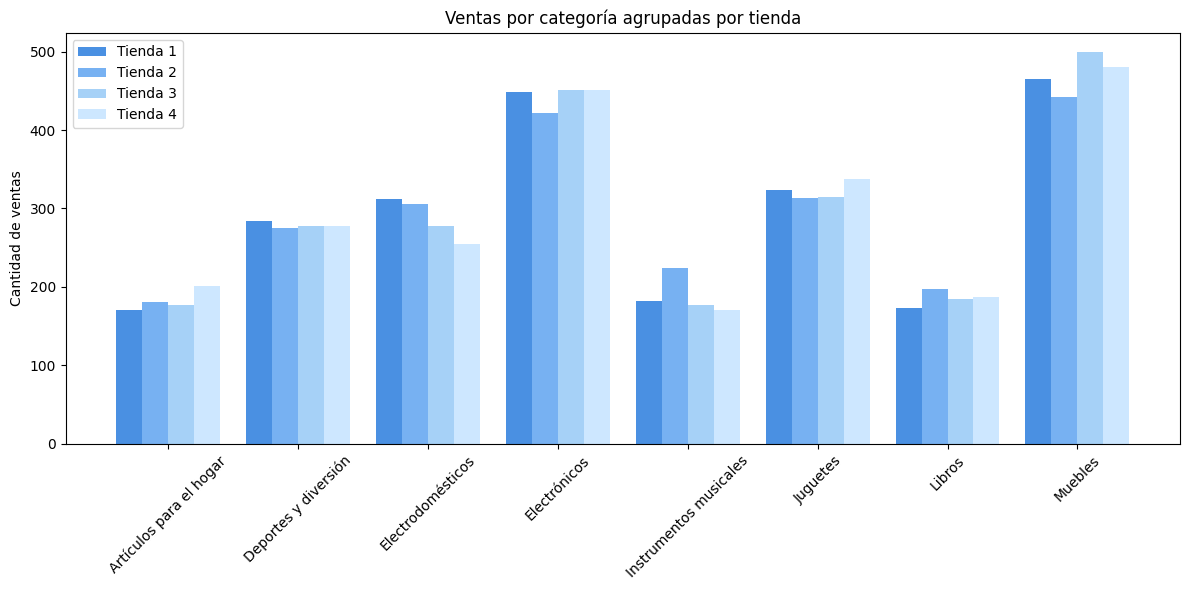

In [82]:
import numpy as np
import matplotlib.pyplot as plt

categorias = df_categorias.index
n_categorias = len(categorias)

tiendas = df_categorias.columns
n_tiendas = len(tiendas)

colores = ["#4A90E2", "#77B1F2", "#A6D1F7", "#CDE7FF"]

x = np.arange(n_categorias)
ancho = 0.2

plt.figure(figsize=(12,6))

for i, tienda in enumerate(tiendas):
    plt.bar(x + i*ancho,
            df_categorias[tienda],
            width=ancho,
            label=tienda,
            color=colores[i])

plt.xticks(x + ancho*1.5, categorias, rotation=45)
plt.ylabel("Cantidad de ventas")
plt.title("Ventas por categoría agrupadas por tienda")
plt.legend()
plt.tight_layout()
plt.show()

# 3. Calificación promedio de la tienda


In [83]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

valoracion_t1 = tienda["Calificación"].mean()
valoracion_t2 = tienda2["Calificación"].mean()
valoracion_t3 = tienda3["Calificación"].mean()
valoracion_t4 = tienda4["Calificación"].mean()

valoraciones = {
    "Tienda 1": round(valoracion_t1, 2),
    "Tienda 2": round(valoracion_t2, 2),
    "Tienda 3": round(valoracion_t3, 2),
    "Tienda 4": round(valoracion_t4, 2),
}

valoraciones

{'Tienda 1': np.float64(3.98),
 'Tienda 2': np.float64(4.04),
 'Tienda 3': np.float64(4.05),
 'Tienda 4': np.float64(4.0)}

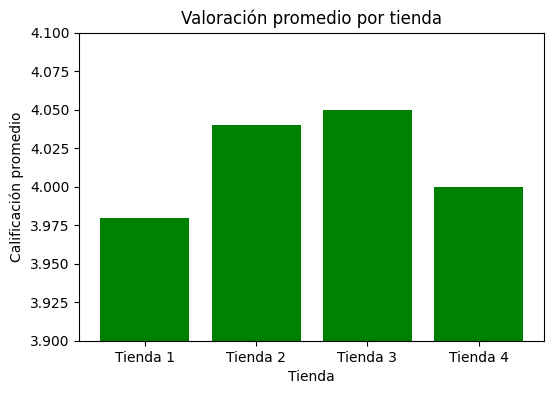

In [84]:
plt.figure(figsize=(6,4))
plt.bar(valoraciones.keys(), valoraciones.values(), color="green")
plt.title("Valoración promedio por tienda")
plt.ylabel("Calificación promedio")
plt.xlabel("Tienda")
plt.xticks(rotation=0)
plt.ylim(3.9, 4.1)
plt.show()

# 4. Productos más y menos vendidos

In [85]:
import pandas as pd

df_productos = pd.DataFrame({
    "Tienda": ["Tienda 1", "Tienda 2", "Tienda 3", "Tienda 4"],
    "Más vendido": [
        tienda["Producto"].value_counts().idxmax(),
        tienda2["Producto"].value_counts().idxmax(),
        tienda3["Producto"].value_counts().idxmax(),
        tienda4["Producto"].value_counts().idxmax()
    ],
    "Menos vendido": [
        tienda["Producto"].value_counts().idxmin(),
        tienda2["Producto"].value_counts().idxmin(),
        tienda3["Producto"].value_counts().idxmin(),
        tienda4["Producto"].value_counts().idxmin()
    ]
})

df_productos

,Tienda,Más vendido,Menos vendido
0,Tienda 1,Microondas,Auriculares con micrófono
1,Tienda 2,Iniciando en programación,Juego de mesa
2,Tienda 3,Kit de bancas,Bloques de construcción
3,Tienda 4,Cama box,Guitarra eléctrica


# 5. Envío promedio por tienda

In [86]:
envio_t1 = tienda["Costo de envío"].mean()
envio_t2 = tienda2["Costo de envío"].mean()
envio_t3 = tienda3["Costo de envío"].mean()
envio_t4 = tienda4["Costo de envío"].mean()

envios_promedio = {
    "Tienda 1": round(envio_t1, 2),
    "Tienda 2": round(envio_t2, 2),
    "Tienda 3": round(envio_t3, 2),
    "Tienda 4": round(envio_t4, 2),
}

df_envios = pd.DataFrame(list(envios_promedio.items()),
                         columns=["Tienda", "Costo de envío promedio"])

df_envios

,Tienda,Costo de envío promedio
0,Tienda 1,26018.61
1,Tienda 2,25216.24
2,Tienda 3,24805.68
3,Tienda 4,23459.46


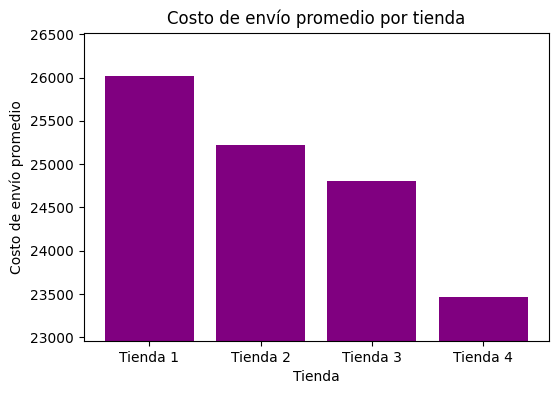

In [87]:
plt.figure(figsize=(6,4))
plt.bar(df_envios["Tienda"], df_envios["Costo de envío promedio"], color="purple")
plt.title("Costo de envío promedio por tienda")
plt.ylabel("Costo de envío promedio")
plt.xlabel("Tienda")

plt.ylim(df_envios["Costo de envío promedio"].min() - 500,
         df_envios["Costo de envío promedio"].max() + 500)

plt.xticks(rotation=0)
plt.show()

#Informe Final
##Introducción
El propósito de este informe es analizar el desempeño de cuatro tiendas con el fin de determinar cuál de ellas representa la mejor opción para que el Sr. Juan venda sus productos. Para ello, se realizó un estudio basado en diversas métricas clave: los ingresos totales de cada tienda, la distribución de ventas por categoría de productos, la calificación promedio otorgada por los clientes, los productos más y menos vendidos, y el costo de envío promedio.
A través de gráficos y análisis comparativos, se busca identificar cuál tienda presenta el ambiente comercial más favorable, considerando tanto la actividad económica como la satisfacción del cliente y el comportamiento de compra.

##Análisis

1. Análisis de facturación:
El análisis mostró diferencias claras entre los volúmenes de venta de cada tienda. La Tienda 1 obtuvo el mayor ingreso total, seguida por las Tiendas 2 y 3, mientras que la Tienda 4 registró el ingreso más bajo. Esto indica que la Tienda 1 posee un flujo de ventas más alto y, por ende, un mercado más activo. Este comportamiento sugiere un mayor potencial comercial para nuevos productos.
2. Ventas por categoría:
Al examinar la distribución de productos vendidos según categoría, se observó que la Tienda 1 y la Tienda 2 destacan por un mayor volumen de ventas en categorías como Electrónicos y Muebles. La Tienda 3 presenta una distribución relativamente equilibrada entre categorías, mientras que la Tienda 4 muestra actividad más moderada.
La presencia de categorías dinámicas y con alta rotación es un indicio importante de demanda. En este sentido, las Tiendas 1 y 2 cuentan con un perfil más atractivo para introducir nuevos productos.
3. Calificación promedio de los clientes:
Las calificaciones promedio se concentraron en un rango estrecho entre 3.98 y 4.05. Aunque todas las tiendas muestran niveles consistentes de satisfacción, las Tiendas 2 y 3 presentan las valoraciones ligeramente más altas. Sin embargo, la diferencia es mínima, por lo que este factor no representa una desventaja significativa para ninguna tienda.
4. Productos más y menos vendidos:
En todas las tiendas se observaron productos con alta rotación y otros con pocas ventas. Las Tiendas 1, 2 y 3 mostraron una mayor dinámica en la variación de productos vendidos, reflejando un mercado más activo y diversificado. La Tienda 4, en cambio, destacó menos en este aspecto, lo que es coherente con su menor volumen de ingresos.
Este punto refuerza la idea de que las tres primeras tiendas poseen un entorno comercial más favorable para la venta de múltiples tipos de productos.
5. Costo de envío promedio:
Los costos de envío promedio no presentaron diferencias significativas entre tiendas. Aunque existen ligeras variaciones, ninguna representa una ventaja o desventaja considerable para los compradores. Esto indica que los costos de envío no son un factor determinante en la elección final de la tienda.

##Conclusión

Luego de analizar los ingresos totales, las categorías de productos más vendidas, la valoración de los clientes, los productos con mayor y menor rotación, y los costos de envío, se concluye que la Tienda 1 es la alternativa más recomendable para que el Sr. Juan venda sus productos.

###Razones principales:
1.	Mayor nivel de ingresos, reflejando un mercado más activo y con mayor volumen de ventas.
2.	Categorías con fuerte demanda, especialmente en áreas donde los productos tienden a rotar más.
3.	Buen equilibrio entre ventas, satisfacción del cliente y diversidad de productos vendidos.
4.	Costos de envío competitivos, sin desventajas respecto a otras tiendas.
En conjunto, estos factores posicionan a la Tienda 1 como la opción más sólida, rentable y estratégica para la comercialización de los productos del Sr. Juan.
